# **Biological stability analysis**

In [1]:
import harreman
import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import muon as mu
import seaborn as sns
import matplotlib.pyplot as plt
import mplscience
from itertools import combinations
from scipy.stats import spearmanr, kruskal, mannwhitneyu, wilcoxon
from statsmodels.stats.multitest import multipletests
from plotnine import *
import warnings
warnings.filterwarnings("ignore")


BASE_PATH = "/home/projects/nyosef/oier/Harreman_files/Slide_seq_lung"
ADATA_PATH = os.path.join(BASE_PATH, 'h5ads')
DATA_PATH = os.path.join(BASE_PATH, 'data')
PLOTS_PATH = os.path.join(BASE_PATH, 'plots')

/home/projects/nyosef/oier/mambaforge/envs/harreman_pip-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/projects/nyosef/oier/mambaforge/envs/harreman_pip-env/lib/python3.12/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
COLOC_COLS = [
    'E2__ESR1', 'E2__ESR2', 'thromboxane__TBXA2R',
    'GABA__GABRA1', 'GABA__GABRG2', 'testosterone__AR',
    'dopamine__DRD1', 'dopamine__DRD2', 'dopamine__DRD3',
    'dopamine__DRD4', 'dopamine__DRD5',
]
 
METHOD_COLORS = {'Harreman': '#D9D9D9', 'scCellFie': '#B2ABD2'}
THEME_BASE = theme(
    legend_position='none',           
    strip_text = element_text(size = 14),
    axis_title_x=element_text(size=16),
    axis_title_y=element_text(size=16),
    axis_text_x=element_text(size=14, rotation=30, hjust=1),
    axis_text_y=element_text(size=14),
    panel_border=element_rect(color='black'),
    panel_background=element_rect(colour='black', linewidth=1),
    figure_size=(6, 4),
)

In [3]:
harreman_adata = sc.read_h5ad(f'{ADATA_PATH}/Slide_seq_lung_Harreman_adata.h5ad')

In [4]:
ccc_sccellfie_adata = sc.read_h5ad(f"{ADATA_PATH}/Slide_seq_lung_CCC_scCellFie.h5ad")

In [5]:
ccc_sccellfie_adata

AnnData object with n_obs × n_vars = 49207 × 21603
    obs: 'n_genes', 'n_UMIs', 'log10_n_UMIs', 'log10_n_genes', 'organism_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'Cell_Type', 'cell_type_ontology_term_id', 'donor_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'sample', 'E2__ESR1', 'E2__ESR2', 'GABA__GABRG2', 'dopamine__DRD2', 'dopamine__DRD3', 'dopamine__DRD4', 'testosterone__AR', 'thromboxane__TBXA2R'
    uns: 'neighbors', 'normalization', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    layers: 'counts', 'log_norm', 'normalized'
    obsp: 'connectivities', 'distances'

## Functions

In [6]:
# ---------------------------------------------------------------------------
# 1.  Build score matrices
# ---------------------------------------------------------------------------
 
def build_score_matrices(harreman_adata, ccc_sccellfie_adata,
                         metadata_df, coloc_cols=None):
    """
    Extract Harreman exchange scores and scCellFie colocalization scores
    aligned to metadata_df index.
    """
    if coloc_cols is None:
        coloc_cols = COLOC_COLS
 
    harreman_scores = pd.DataFrame(
        harreman_adata.uns['interacting_cell_results']['np']['m']['cs'],
        index=harreman_adata.obs_names,
        columns=harreman_adata.uns['metabolites'],
    )
 
    available_cols = [c for c in coloc_cols if c in ccc_sccellfie_adata.obs.columns]
    missing = set(coloc_cols) - set(available_cols)
    if missing:
        print(f"Warning: missing colocalization columns: {missing}")
 
    sccellfie_scores = ccc_sccellfie_adata.obs[available_cols].copy()
 
    common_h = harreman_scores.index.intersection(metadata_df.index)
    common_s = sccellfie_scores.index.intersection(metadata_df.index)
 
    harreman_scores = harreman_scores.loc[common_h]
    sccellfie_scores = sccellfie_scores.loc[common_s]
 
    print(f"Harreman scores:  {harreman_scores.shape}")
    print(f"scCellFie scores: {sccellfie_scores.shape}")
    print(f"scCellFie pairs:  {available_cols}")
 
    return harreman_scores, sccellfie_scores

In [7]:
# ---------------------------------------------------------------------------
# 2.  Long-format builder
# ---------------------------------------------------------------------------
 
def make_long_score_df(score_df, metadata_df, method_name,
                       sample_col='sample', region_col='tissue_type'):
    common_index = score_df.index.intersection(metadata_df.index)
    score_df = score_df.loc[common_index].copy()
    metadata_df = metadata_df.loc[common_index].copy()
 
    long_df = (
        score_df
        .reset_index(names='spot')
        .melt(id_vars='spot', var_name='event', value_name='score')
    )
    meta = metadata_df.reset_index(names='spot')[['spot', sample_col, region_col]]
    long_df = long_df.merge(meta, on='spot', how='left')
    long_df['method'] = method_name
    return long_df

In [8]:
# ---------------------------------------------------------------------------
# 3.  Region effects
# ---------------------------------------------------------------------------
 
def compute_region_effects(scores_df, sample_col='sample',
                           region_col='tissue_type'):
    """
    Z-score per slide x method x event, compute region effect:
    mean(z in region) - mean(z outside region).
    + 1e-8 denominator prevents division by zero for constant events.
    """
    scores_df = scores_df.copy()
 
    scores_df['score_z'] = (
        scores_df
        .groupby([sample_col, 'method', 'event'])['score']
        .transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))
    )
 
    results = []
    for (slide, method, event), df in scores_df.groupby(
            [sample_col, 'method', 'event']):
        for region in df[region_col].unique():
            in_r  = df.loc[df[region_col] == region, 'score_z']
            out_r = df.loc[df[region_col] != region, 'score_z']
            if len(in_r) < 5 or len(out_r) < 5:
                continue
            results.append({
                'slide':  slide,
                'method': method,
                'event':  event,
                'region': region,
                'effect': in_r.mean() - out_r.mean(),
            })
 
    return pd.DataFrame(results)

In [9]:
# ---------------------------------------------------------------------------
# 4.  Metric 1 — Spearman correlation of effects
# ---------------------------------------------------------------------------
 
def compute_spearman_reproducibility(region_effects_df):
    """
    Spearman rho of region effect sizes between every slide pair,
    per (method, region).
    """
    results = []
    for (method, region), df in region_effects_df.groupby(['method', 'region']):
        pivot = df.pivot_table(index='event', columns='slide', values='effect')
        slides = pivot.columns.tolist()
        for s1, s2 in combinations(slides, 2):
            x, y = pivot[s1], pivot[s2]
            mask = x.notna() & y.notna()
            if mask.sum() < 3:
                continue
            rho, _ = spearmanr(x[mask], y[mask])
            results.append({'method': method, 'region': region,
                            'slide1': s1, 'slide2': s2, 'rho': rho})
    return pd.DataFrame(results)

In [10]:
# ---------------------------------------------------------------------------
# 5.  Metric 2 — Jaccard of top-20% events
# ---------------------------------------------------------------------------
 
def compute_jaccard_reproducibility(region_effects_df, top_k_frac=0.20):
    """
    Top top_k_frac of events by absolute effect per (slide, method, region).
    Jaccard similarity of selected event sets between every slide pair.
 
    Uses fraction instead of fixed k so Harreman (~240 events) and
    scCellFie (~8 events) are treated proportionally.
    """
    df = region_effects_df.copy()
    df['abs_effect'] = df['effect'].abs()
 
    n_events = df.groupby(['slide', 'method', 'region'])['event'].transform('count')
    df['top_k'] = (n_events * top_k_frac).astype(int).clip(lower=3)
    df['rank'] = (
        df.groupby(['slide', 'method', 'region'])['abs_effect']
        .rank(ascending=False, method='first')
    )
    top_df = df[df['rank'] <= df['top_k']].copy()
 
    results = []
    for (method, region), grp in top_df.groupby(['method', 'region']):
        slides = grp['slide'].unique()
        top_k_val = int(grp['top_k'].median())
        for s1, s2 in combinations(slides, 2):
            set1 = set(grp[grp['slide'] == s1]['event'])
            set2 = set(grp[grp['slide'] == s2]['event'])
            union = set1 | set2
            if not union:
                continue
            results.append({
                'method': method, 'region': region,
                'slide1': s1, 'slide2': s2,
                'jaccard': len(set1 & set2) / len(union),
                'top_k': top_k_val,
            })
    return pd.DataFrame(results)

In [11]:
# ---------------------------------------------------------------------------
# 6.  Metric 3 — Rank correlation stability (new)
# ---------------------------------------------------------------------------
 
def compute_rank_stability(region_effects_df):
    """
    Rank events by absolute effect within each (slide, method, region).
    Compute Spearman correlation of ranks between every slide pair.
 
    Answers: do slides agree on *which* events are most important,
    regardless of effect magnitude? Complements Metric 1 (magnitude
    correlation) and Metric 2 (hard top-k overlap).
    """
    df = region_effects_df.copy()
    df['abs_effect'] = df['effect'].abs()
    df['rank'] = (
        df.groupby(['slide', 'method', 'region'])['abs_effect']
        .rank(ascending=False, method='average')
    )
 
    results = []
    for (method, region), grp in df.groupby(['method', 'region']):
        pivot = grp.pivot_table(index='event', columns='slide', values='rank')
        slides = pivot.columns.tolist()
        for s1, s2 in combinations(slides, 2):
            x, y = pivot[s1], pivot[s2]
            mask = x.notna() & y.notna()
            if mask.sum() < 3:
                continue
            rho, _ = spearmanr(x[mask], y[mask])
            results.append({
                'method': method, 'region': region,
                'slide1': s1, 'slide2': s2, 'rank_rho': rho,
            })
    return pd.DataFrame(results)

In [12]:
# ---------------------------------------------------------------------------
# 7.  Statistical comparison between methods
# ---------------------------------------------------------------------------
 
def compare_methods(repro_df, metric_col):
    """Per-region Mann-Whitney U: Harreman vs scCellFie."""
    rows = []
    for region, grp in repro_df.groupby('region'):
        h = grp[grp['method'] == 'Harreman'][metric_col].dropna()
        s = grp[grp['method'] == 'scCellFie'][metric_col].dropna()
        if len(h) < 2 or len(s) < 2:
            continue
        stat, p = mannwhitneyu(h, s, alternative='two-sided')
        rows.append({
            'region': region, 'U': stat, 'pvalue': p,
            'harreman_median': h.median(),
            'sccellfie_median': s.median(),
            'n_harreman': len(h), 'n_sccellfie': len(s),
        })
    stats_df = pd.DataFrame(rows)
    if not stats_df.empty:
        stats_df['padj'] = multipletests(stats_df['pvalue'], method='fdr_bh')[1]
        stats_df['sig'] = stats_df['padj'].apply(
            lambda p: '***' if p < 0.001 else (
                '**' if p < 0.01 else ('*' if p < 0.05 else 'ns')))
    return stats_df

In [13]:
# ---------------------------------------------------------------------------
# 8.  Plots
# ---------------------------------------------------------------------------
 
def _base_repro_plot(df, y_col, y_lab, stats_df=None):
    fig = (
        ggplot(df, aes('method', y_col, fill='method'))
        + geom_boxplot(position=position_dodge(width=0.8), outlier_shape="", color='black', width=0.5)
        + geom_jitter(width=0.15, height=0, size=1, alpha=0.5)
        + facet_wrap('~region')
        + scale_fill_manual(values=METHOD_COLORS)
        + ylim(0, 1)
        + theme_classic()
        + THEME_BASE
        + labs(x='', y=y_lab)
    )

    if stats_df is not None and not stats_df.empty:
        sig_df = stats_df[stats_df['sig'] != 'ns'].copy()
        if not sig_df.empty:
            fig = (
                fig
                + geom_segment(
                    data=sig_df,
                    mapping=aes(x='x_left', xend='x_right', y='y', yend='y'),
                    inherit_aes=False,
                    color='black',
                    size=0.5,
                )
                + geom_text(
                    data=sig_df,
                    mapping=aes(x=1.5, y='star_y', label='sig'),
                    inherit_aes=False,
                    size=12,
                    ha='center',
                )
            )

    return fig

 
def plot_spearman(repro_df, stats_df=None, save_path=None):
    fig = _base_repro_plot(repro_df, 'rho',
                           'Reproducibility across slides (Spearman ρ)')
    fig.show()
    if save_path:
        fig.save(save_path)
    return fig
 
 
def plot_jaccard(overlap_df, stats_df=None, save_path=None):
    fig = _base_repro_plot(overlap_df, 'jaccard',
                           'Top 20% event overlap across slides (Jaccard)')
    fig.show()
    if save_path:
        fig.save(save_path)
    return fig
 
 
def plot_rank_stability(rank_df, stats_df=None, save_path=None):
    fig = _base_repro_plot(rank_df, 'rank_rho',
                           'Rank stability across slides (Spearman ρ of ranks)')
    fig.show()
    if save_path:
        fig.save(save_path)
    return fig
 
 
def plot_global_summary(repro_df, overlap_df, rank_df, save_path=None):
    """
    Combined violin + boxplot pooling all regions and slide pairs,
    one panel per metric. Single-panel summary for the paper.
    """
    from scipy.stats import mannwhitneyu
    
    combined = pd.concat([
        repro_df[['method', 'rho']].rename(
            columns={'rho': 'value'}).assign(metric='Spearman ρ\n(effect size)'),
        overlap_df[['method', 'jaccard']].rename(
            columns={'jaccard': 'value'}).assign(metric='Jaccard\n(top 20%)'),
        rank_df[['method', 'rank_rho']].rename(
            columns={'rank_rho': 'value'}).assign(metric='Spearman ρ\n(rank stability)'),
    ], ignore_index=True)
 
    print("\n--- Global summary (all regions pooled) ---")
    for metric in combined['metric'].unique():
        h = combined[(combined['method'] == 'Harreman') &
                     (combined['metric'] == metric)]['value'].dropna()
        s = combined[(combined['method'] == 'scCellFie') &
                     (combined['metric'] == metric)]['value'].dropna()
        if len(h) >= 2 and len(s) >= 2:
            _, p = mannwhitneyu(h, s, alternative='two-sided')
            print(f"  {metric.replace(chr(10), ' ')}: "
                  f"Harreman={h.median():.3f}, "
                  f"scCellFie={s.median():.3f}, p={p:.3e}")
 
    global_stats_rows = []
    for metric_label, val_col, df in [
        ('Spearman ρ\n(effect size)',  'rho',      repro_df),
        ('Jaccard\n(top 20%)',         'jaccard',   overlap_df),
        ('Spearman ρ\n(rank stability)','rank_rho', rank_df),
    ]:
        h = df[df['method'] == 'Harreman'][val_col].dropna()
        s = df[df['method'] == 'scCellFie'][val_col].dropna()
        if len(h) >= 2 and len(s) >= 2:
            from scipy.stats import mannwhitneyu
            _, p = mannwhitneyu(h, s, alternative='two-sided')
            sig = '***' if p < 0.001 else ('**' if p < 0.01 else 
                ('*' if p < 0.05 else 'ns'))
            global_stats_rows.append({
                'metric':   metric_label,
                'sig':      sig,
                'y':        df[val_col].max() + 0.03,
                'star_y':   df[val_col].max() + 0.03 + 0.01,
                'x_left':   1.0,
                'x_right':  2.0,
            })

    global_stats_df = pd.DataFrame(global_stats_rows)
    sig_global_df   = global_stats_df[global_stats_df['sig'] != 'ns'].copy()
    
    fig = (
        ggplot(combined, aes('method', 'value', fill='method'))
        + geom_boxplot(position=position_dodge(width=0.8), outlier_shape="", color='black', width=0.5)
        + geom_jitter(width=0.15, height=0, size=1, alpha=0.5)
        + geom_segment(
            data=sig_global_df,
            mapping=aes(x='x_left', xend='x_right', y='y', yend='y'),
            inherit_aes=False,
            color='black',
            size=0.5,
        )
        + geom_text(
            data=sig_global_df,
            mapping=aes(x=1.5, y='star_y', label='sig'),
            inherit_aes=False,
            size=12,
            ha='center',
        )
        + facet_wrap('~metric', nrow=1)
        + scale_fill_manual(values=METHOD_COLORS)
        # + ylim(0, 1)
        + theme_classic()
        + theme(
            legend_position='none',
            strip_text = element_text(size = 14),
            axis_title_x=element_text(size=16),
            axis_title_y=element_text(size=16),
            axis_text_x=element_text(size=14, rotation=30, hjust=1),
            axis_text_y=element_text(size=14),
            panel_border=element_rect(color='black'),
            figure_size=(6, 4),
        )
        + labs(x='', y='Reproducibility score')
    )
    fig.show()
    if save_path:
        fig.save(save_path)
    return fig

In [14]:
def add_star_y_repro(stats_df, repro_df, value_col='rho', offset_frac=0.05):
    """
    Add star placement and bracket segment columns to reproducibility
    stats_df (output of compare_methods()).

    Columns added:
        y        : y position of horizontal bracket
        star_y   : y position of significance label
        x_left   : left x of bracket (Harreman, position 1)
        x_right  : right x of bracket (scCellFie, position 2)

    Parameters
    ----------
    stats_df : pd.DataFrame   output of compare_methods(), has 'region', 'sig'
    repro_df : pd.DataFrame   long-format reproducibility results with
                              'region', 'method', value_col
    value_col : str           'rho', 'jaccard', or 'rank_rho'
    offset_frac : float
    """
    stats_df = stats_df.copy()

    rows = {}
    for region in stats_df['region']:
        vals = repro_df[
            repro_df['region'] == region
        ][value_col].dropna()

        if len(vals) == 0:
            rows[region] = {'bracket': 1.0, 'range': 0.1}
            continue

        p95    = vals.quantile(0.95)
        vrange = vals.max() - vals.min()
        offset = vrange * offset_frac
        rows[region] = {
            'bracket': p95 + offset,
            'range':   vrange,
        }

    stats_df['y'] = repro_df[value_col].max() + 0.03
    stats_df["star_y"] = stats_df["y"] + 0.01
    stats_df['x_left']  = 1.0
    stats_df['x_right'] = 2.0

    return stats_df

In [15]:
# ---------------------------------------------------------------------------
# 9.  Main runner
# ---------------------------------------------------------------------------
 
def run_reproducibility_benchmark(
    harreman_adata,
    ccc_sccellfie_adata,
    metadata_df,
    coloc_cols=None,
    top_k_frac=0.20,
    plots_path=None,
):
    """
    End-to-end reproducibility benchmark.
 
    Parameters
    ----------
    harreman_adata : AnnData
    ccc_sccellfie_adata : AnnData  with colocalization scores in .obs
    metadata_df : pd.DataFrame     indexed by spot, columns: sample, tissue_type
    coloc_cols : list, optional
    top_k_frac : float             fraction of top events for Jaccard (default 0.20)
    plots_path : str, optional
 
    Returns
    -------
    region_effects_df, repro_df, overlap_df, rank_df,
    spearman_stats, jaccard_stats, rank_stats
    """
    if coloc_cols is None:
        coloc_cols = COLOC_COLS
 
    print("Building score matrices...")
    harreman_scores, sccellfie_scores = build_score_matrices(
        harreman_adata, ccc_sccellfie_adata, metadata_df, coloc_cols)
 
    harreman_long  = make_long_score_df(harreman_scores,  metadata_df, 'Harreman')
    sccellfie_long = make_long_score_df(sccellfie_scores, metadata_df, 'scCellFie')
    scores_df = pd.concat([harreman_long, sccellfie_long], ignore_index=True)
 
    print("Computing region effects...")
    region_effects_df = compute_region_effects(scores_df)
    print(f"  {len(region_effects_df)} rows")
 
    print("Computing reproducibility metrics...")
    repro_df   = compute_spearman_reproducibility(region_effects_df)
    overlap_df = compute_jaccard_reproducibility(region_effects_df, top_k_frac)
    rank_df    = compute_rank_stability(region_effects_df)
 
    spearman_stats = compare_methods(repro_df,   'rho')
    jaccard_stats  = compare_methods(overlap_df, 'jaccard')
    rank_stats     = compare_methods(rank_df,    'rank_rho')
    
    # Apply to each metric
    spearman_stats = add_star_y_repro(
        spearman_stats, repro_df, value_col='rho')
    jaccard_stats  = add_star_y_repro(
        jaccard_stats, overlap_df, value_col='jaccard')
    rank_stats     = add_star_y_repro(
        rank_stats, rank_df, value_col='rank_rho')
 
    print("\n--- Spearman reproducibility ---")
    print(spearman_stats.to_string(index=False, float_format='{:.4f}'.format))
    print("\n--- Jaccard overlap (top 20%) ---")
    print(jaccard_stats.to_string(index=False, float_format='{:.4f}'.format))
    print("\n--- Rank stability ---")
    print(rank_stats.to_string(index=False, float_format='{:.4f}'.format))
 
    sp = os.path.join(plots_path, 'repro_spearman.svg')         if plots_path else None
    jp = os.path.join(plots_path, 'repro_jaccard_top20pct.svg') if plots_path else None
    rp = os.path.join(plots_path, 'repro_rank_stability.svg')   if plots_path else None
    gp = os.path.join(plots_path, 'repro_global_summary.svg')   if plots_path else None
 
    plot_spearman(repro_df,   spearman_stats, save_path=sp)
    plot_jaccard(overlap_df,  jaccard_stats,  save_path=jp)
    plot_rank_stability(rank_df, rank_stats,  save_path=rp)
    plot_global_summary(repro_df, overlap_df, rank_df, save_path=gp)
 
    return (region_effects_df, repro_df, overlap_df, rank_df,
            spearman_stats, jaccard_stats, rank_stats)

## Running the analysis

In [16]:
bead_locations_8 = pd.read_csv(f'{DATA_PATH}/bead_locations_8.csv')
bead_locations_9 = pd.read_csv(f'{DATA_PATH}/bead_locations_9.csv')
bead_locations_10 = pd.read_csv(f'{DATA_PATH}/bead_locations_10.csv')

In [17]:
bead_locations = {
    'Puck_200727_08': bead_locations_8,
    'Puck_200727_09': bead_locations_9,
    'Puck_200727_10': bead_locations_10,
}

In [18]:
samples = ['Puck_200727_08', 'Puck_200727_09', 'Puck_200727_10']
na_color = '#F7F7F7'
bead_locations_list = []
for sample in samples:
    print(sample)
    sample_adata = harreman_adata[harreman_adata.obs['sample'] == sample].copy()
    spatial_df = pd.DataFrame(
        sample_adata.obsm["spatial"],
        columns=["x_coord", "y_coord"],
        index=sample_adata.obs_names
    ).reset_index().rename(columns={"index": "barcode"})
    
    bead_locations_subset = bead_locations[sample].merge(
        spatial_df,
        on=["x_coord", "y_coord"],
        how="inner"
    ).set_index('barcode')
    
    bead_locations_list.append(bead_locations_subset['tissue_type'])

Puck_200727_08
Puck_200727_09
Puck_200727_10


In [19]:
bead_locations_df = pd.concat(bead_locations_list)

In [20]:
metadata_df = harreman_adata.obs[['sample']]
metadata_df = metadata_df.loc[bead_locations_df.index].copy()
metadata_df['tissue_type'] = bead_locations_df

Building score matrices...
Harreman scores:  (49207, 236)
scCellFie scores: (49207, 8)
scCellFie pairs:  ['E2__ESR1', 'E2__ESR2', 'thromboxane__TBXA2R', 'GABA__GABRG2', 'testosterone__AR', 'dopamine__DRD2', 'dopamine__DRD3', 'dopamine__DRD4']
Computing region effects...
  2196 rows
Computing reproducibility metrics...

--- Spearman reproducibility ---
        region      U  pvalue  harreman_median  sccellfie_median  n_harreman  n_sccellfie   padj sig      y  star_y  x_left  x_right
          Lung 9.0000  0.1000           0.9183            0.3114           3            3 0.1500  ns 0.9859  0.9959  1.0000   2.0000
TIL Chemokines 7.0000  0.4000           0.8220            0.4392           3            3 0.4000  ns 0.9859  0.9959  1.0000   2.0000
         Tumor 9.0000  0.1000           0.9111            0.5749           3            3 0.1500  ns 0.9859  0.9959  1.0000   2.0000

--- Jaccard overlap (top 20%) ---
        region      U  pvalue  harreman_median  sccellfie_median  n_harreman  n

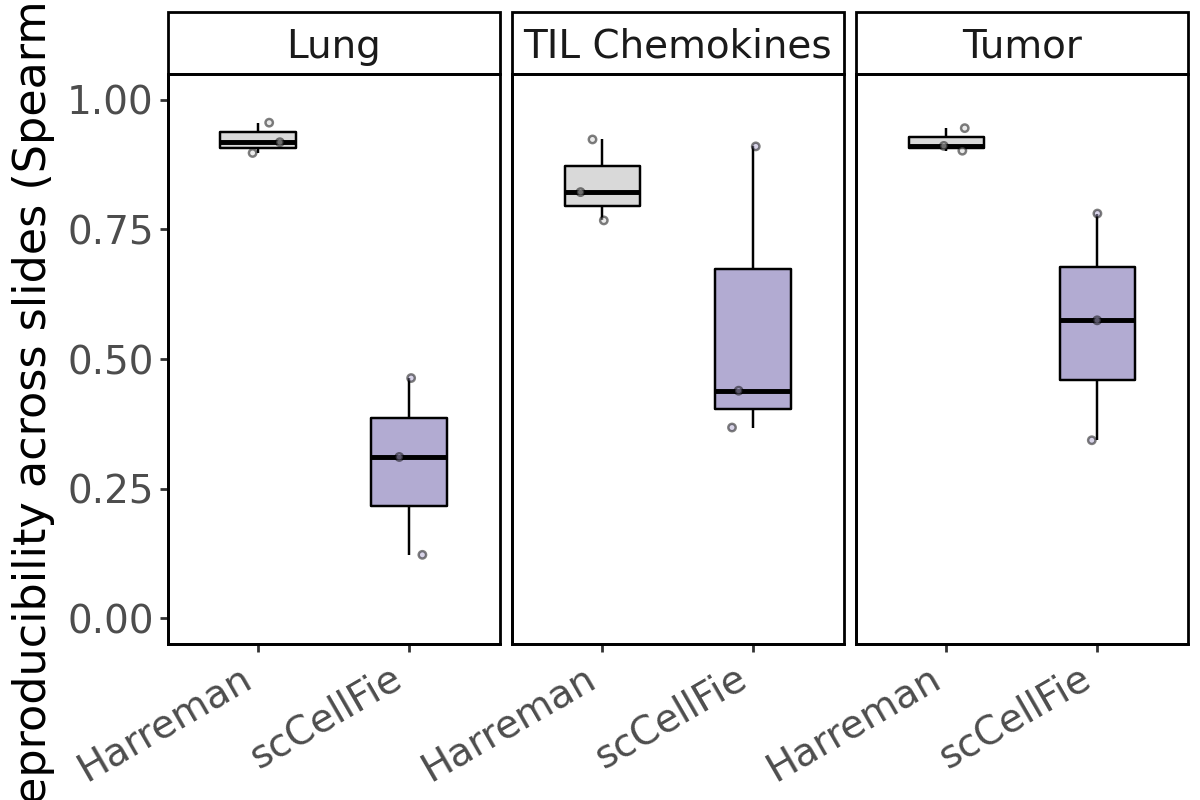

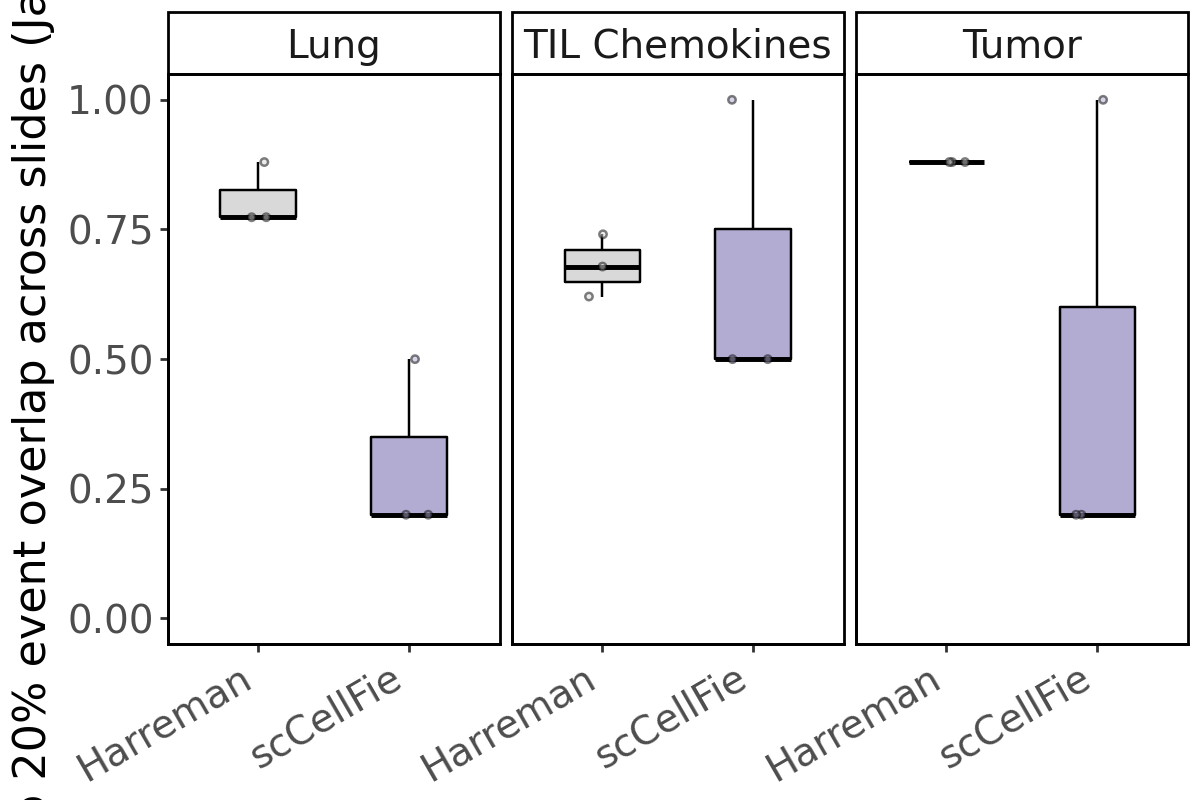

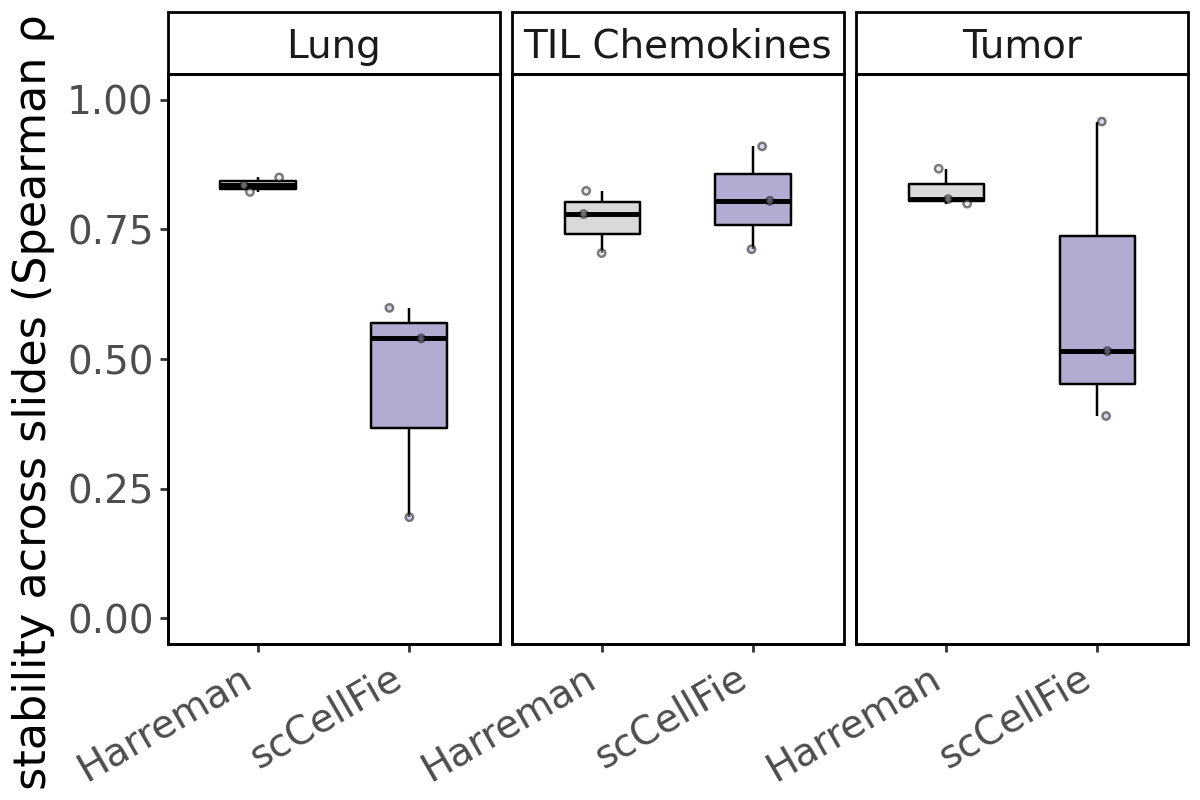


--- Global summary (all regions pooled) ---
  Spearman ρ (effect size): Harreman=0.911, scCellFie=0.439, p=1.998e-03
  Jaccard (top 20%): Harreman=0.774, scCellFie=0.500, p=4.892e-02
  Spearman ρ (rank stability): Harreman=0.822, scCellFie=0.599, p=1.120e-01


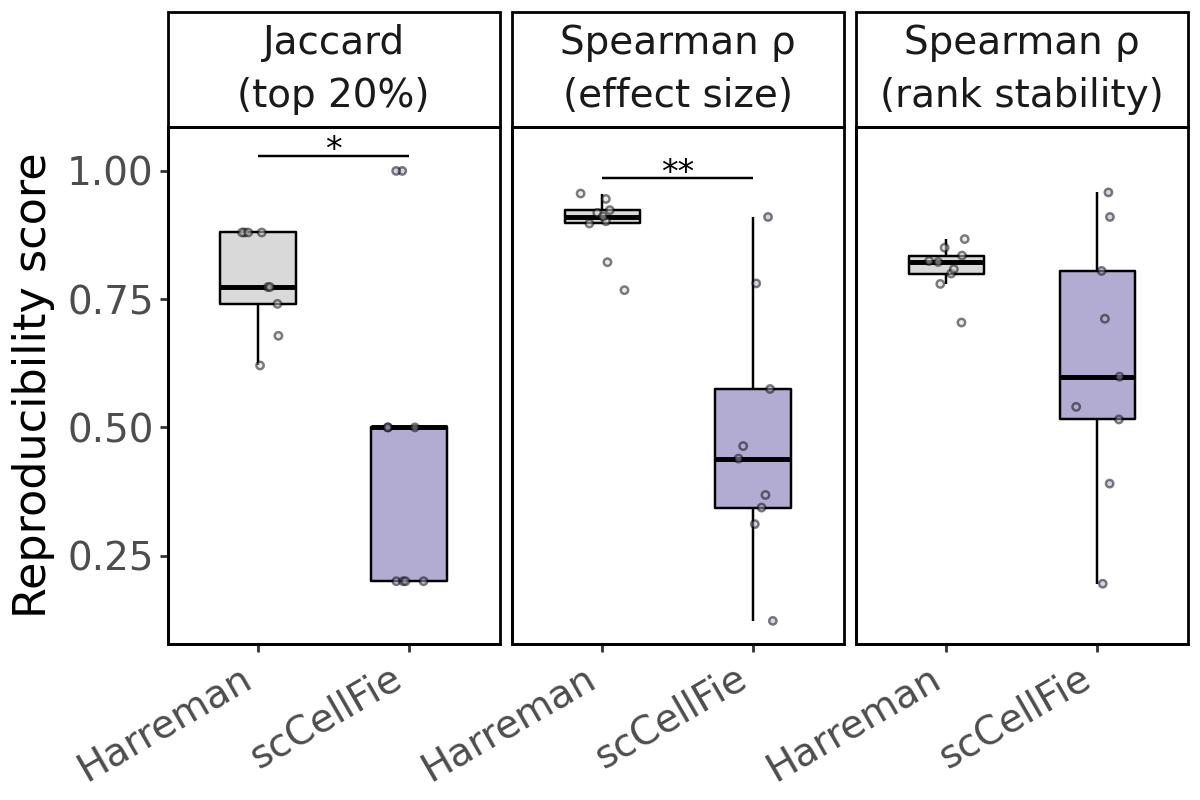

In [21]:
# ---------------------------------------------------------------------------
# 10.  Example usage
# ---------------------------------------------------------------------------
 
(region_effects_df, repro_df, overlap_df, rank_df,
 spearman_stats, jaccard_stats, rank_stats) = run_reproducibility_benchmark(
    harreman_adata=harreman_adata,
    ccc_sccellfie_adata=ccc_sccellfie_adata,
    metadata_df=metadata_df,
    coloc_cols=COLOC_COLS,
    top_k_frac=0.20,
    plots_path=PLOTS_PATH,
)